# Performance of step 2 - Qlearning, single agent

Comparison with the results coming from the meta-algorithm, step1, where there is absolute knowledge and the optimal value is chosen.

### first comparison: same MDPs structure, different transition probabilities
Generate 100 MDPs (based on the principla_agent_mdp.py) with random rewards, execture meta algorithm on each of them and calculate utility and regret

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#MDP 
from principal_agent_mdp import PrincipalAgentMDP

# meta-algo: value iteration, no learning
from meta.agent_meta import AgentMeta
from meta.principal_meta import PrincipalMeta

# q-learning version
from qlearn.agent_qlearn import AgentQLearn
from qlearn.principal_qlearn import PrincipalQLearn


MDP 100/100
Done!
Exact utility  — mean: 392.7000, std: 182.0168
QL utility     — mean: 0.4730,   std: 0.4141
Regret         — mean: 392.2270,    std: 181.8497
Regret %       — mean: 99.87%


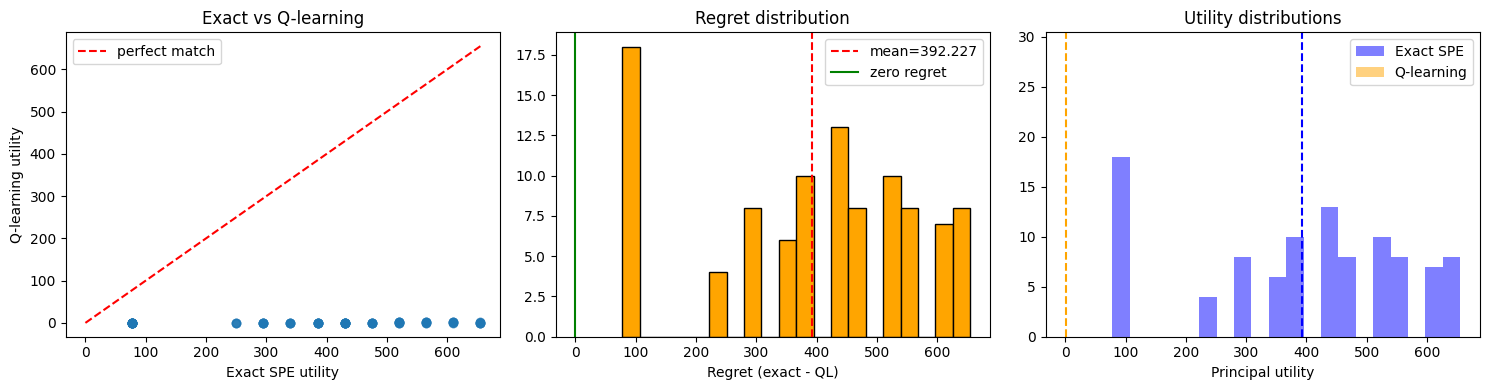

In [ ]:
# ── run parameters ──────────────────────────────────────────────────────────────
N_MDP      = 100
GAMMA      = 1
N_META     = 20
N_EPISODES = 5000
ALPHA      = 0.1
EPSILON    = 0.1

# ── Meta-algorithm (value iteration) ────────────────────────────────
def solve_exact(mdp, r_p):
    agent     = AgentMeta(mdp)
    principal = PrincipalMeta(mdp, r_p, b_grid_step=0.1)
    rho       = {s: np.zeros(2) for s in range(mdp.n_states)}

    for _ in range(N_META):
        V_agent, Q_agent, pi_star = agent.solve(rho)      # agent solves given rho
        principal.solve(agent)                              # principal gets full agent obj
        rho = principal.rho_star                            # feed rho back to next iter

    return principal.V[mdp.s0], rho


# ── Q-learning algo ─────────────────────────────────────────
def solve_qlearning(mdp, r_p):
    """Meta-algorithm with Q-learning — Section 4.
    
    FIXES:
    1. Update Q_bar periodically (every N_UPDATE episodes) instead of freezing it
    2. Add epsilon-greedy exploration for principal's action selection
    3. Clear contract cache after updating Q_bar to avoid stale contracts
    4. Principal learns which contracts work for learned Q-values
    """
    agent     = AgentQLearn(mdp, alpha=ALPHA, epsilon=EPSILON)
    principal = PrincipalQLearn(mdp, r_p, alpha=ALPHA, epsilon=EPSILON)
    rho       = {s: (0.0, 0.0) for s in range(mdp.n_states)}
    
    N_UPDATE = 200  # Update Q_bar every 200 episodes

    for _ in range(N_META):
        agent.reset()
        
        # Phase 1: Agent learns Q_bar
        for episode in range(N_EPISODES):
            s = mdp.s0
            while not mdp.is_terminal(s):
                b      = rho[s]
                a      = agent.act(s, b)
                o      = mdp.sample_outcome(s, a)
                s_next = mdp.T(s, o)
                b_next = rho[s_next]
                agent.update(s, a, o, s_next, b_next)
                s = s_next

        # Phase 2: Principal learns contracts based on CURRENT agent Q_bar
        principal.reset()
        
        # Get fresh Q_bar from agent
        Q_bar = agent.get_Q_bar()

        for episode in range(N_EPISODES):
            # Periodically refresh Q_bar and clear cache (every N_UPDATE episodes)
            if episode % N_UPDATE == 0:
                Q_bar = agent.get_Q_bar()
                principal._contract_cache.clear()  # Force recomputation of contracts
            
            s = mdp.s0
            while not mdp.is_terminal(s):
                # ── Principal selects action with epsilon-greedy ──
                if np.random.rand() < EPSILON:
                    a_p = np.random.randint(mdp.n_actions)  # explore
                else:
                    a_p = int(np.argmax(principal.q[s]))    # exploit
                
                # Find cheapest contract to induce a_p given current Q_bar
                b = principal.find_best_contract(s, a_p, Q_bar)
                
                # Environment step
                o = mdp.sample_outcome(s, a_p)
                s_next = mdp.T(s, o)
                
                # Principal update
                principal.update(s, a_p, b, o, s_next)
                s = s_next

        # Extract learned policy as contracts
        for s in range(mdp.n_states):
            best_a_p = int(np.argmax(principal.q[s]))
            rho[s] = principal.find_best_contract(s, best_a_p, Q_bar)

    # evaluate learned utility
    return evaluate_utility(mdp, rho) 


def evaluate_utility(mdp, rho, n_eval=1000):
    """Monte Carlo evaluation of principal utility under rho."""
    returns = []
    for _ in range(n_eval):
        s, vp, t = mdp.s0, 0.0, 0
        while not mdp.is_terminal(s):
            b = rho[s] if not isinstance(rho[s], tuple) else np.array(rho[s])
            Q_full = np.array([
                sum(mdp.P_outcome[s, a, o] * mdp.R_agent(s, a, b, o)
                    for o in range(mdp.n_outcomes))
                for a in range(mdp.n_actions)
            ])
            a   = int(np.argmax(Q_full))
            o   = mdp.sample_outcome(s, a)
            vp += (GAMMA**t) * mdp.R_principal(s, b, o)
            t  += 1
            s   = mdp.T(s, o)
        returns.append(vp)
    return np.mean(returns)


# ── Main ───────────────────────────────────────────────────────────────────
exact_utils = []
ql_utils    = []
regrets     = []

for i in range(N_MDP):  
    print(f"MDP {i+1}/{N_MDP}", end='\r')

    mdp     = PrincipalAgentMDP(gamma=GAMMA)


    #randomize action

    cost_aL = np.random.uniform(0, 1)

    # Randomize transition/outcome probabilities
    for s in range(mdp.n_states):
        for a in range(mdp.n_actions):
            probs = np.random.dirichlet(3* np.ones(mdp.n_outcomes))  #probabilites generated with Dirichlet3
            mdp.P_outcome[s, a, :] = probs #removed for sanity check

    r_p = np.zeros((mdp.n_states, mdp.n_outcomes))

    for s in range(mdp.n_states):
        r_p[s, 0] = 14 / 9
        r_p[s, 1] = 0.0

    def R_agent_rand(s, a, b, o, c=cost_aL):
        return (-c if a == 0 else 0.0) + b[o]

    def R_principal_rand(s, b, o, rp=r_p):
        return rp[s, o] - b[o]

    mdp.R_agent     = R_agent_rand
    mdp.R_principal = R_principal_rand

    u_exact, _  = solve_exact(mdp, r_p)
    u_ql        = solve_qlearning(mdp, r_p)

    exact_utils.append(u_exact)
    ql_utils.append(u_ql)
    regrets.append(u_exact - u_ql)

    

print("\nDone!")
print(f"Exact utility  — mean: {np.mean(exact_utils):.4f}, std: {np.std(exact_utils):.4f}")
print(f"QL utility     — mean: {np.mean(ql_utils):.4f},   std: {np.std(ql_utils):.4f}")
print(f"Regret         — mean: {np.mean(regrets):.4f},    std: {np.std(regrets):.4f}")
print(f"Regret %       — mean: {np.mean(np.array(regrets)/(np.array(exact_utils)+1e-9)*100):.2f}%")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(exact_utils, ql_utils, alpha=0.5)
lims = [min(exact_utils+ql_utils), max(exact_utils+ql_utils)]
axes[0].plot(lims, lims, 'r--', label='perfect match')
axes[0].set_xlabel('Exact SPE utility')
axes[0].set_ylabel('Q-learning utility')
axes[0].set_title('Exact vs Q-learning')
axes[0].legend()

axes[1].hist(regrets, bins=20, edgecolor='black', color='orange')
axes[1].axvline(np.mean(regrets), color='red', linestyle='--',
                label=f"mean={np.mean(regrets):.3f}")
axes[1].axvline(0, color='green', linestyle='-', label='zero regret')
axes[1].set_title('Regret distribution')
axes[1].set_xlabel('Regret (exact - QL)')
axes[1].legend()

axes[2].hist(exact_utils, bins=20, alpha=0.5, label='Exact SPE', color='blue')
axes[2].hist(ql_utils,    bins=20, alpha=0.5, label='Q-learning', color='orange')
axes[2].axvline(np.mean(exact_utils), color='blue',   linestyle='--')
axes[2].axvline(np.mean(ql_utils),    color='orange', linestyle='--')
axes[2].set_title('Utility distributions')
axes[2].set_xlabel('Principal utility')
axes[2].legend()

plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

Text(0, 0.5, 'Cumulative regret')

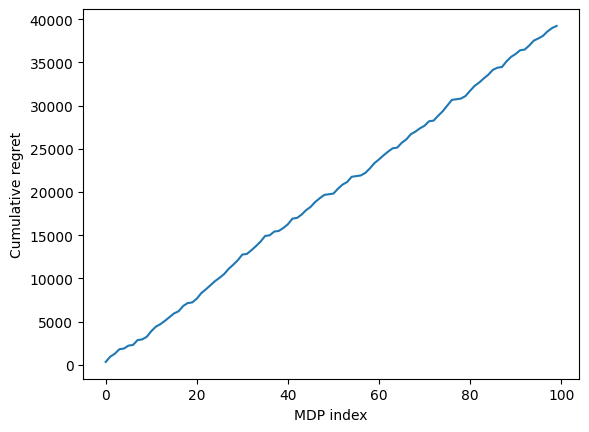

In [3]:
cum_regret = np.cumsum(regrets)

plt.plot(cum_regret)
plt.xlabel("MDP index")
plt.ylabel("Cumulative regret")

MDP 10/10
Done!
Exact utility  — mean: 427.8356, std: 128.4869
QL utility     — mean: 0.8452,   std: 0.3378
Regret         — mean: 426.9904,    std: 128.4418
Regret %       — mean: 99.79%


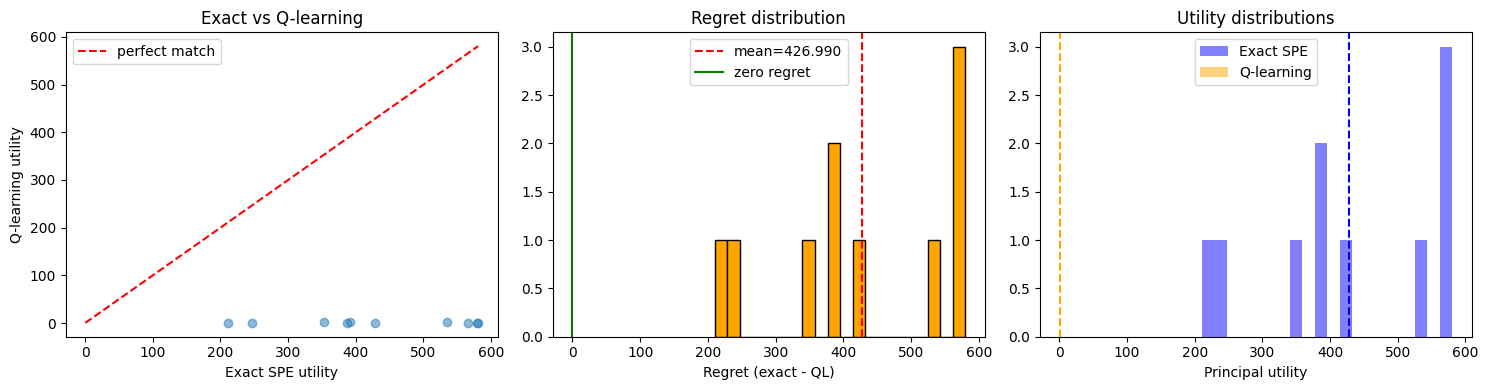

In [3]:
# ── run parameters ──────────────────────────────────────────────────────────────
N_MDP      = 10
GAMMA      = 1
N_META     = 20
N_EPISODES = 5000
ALPHA      = 0.1
EPSILON    = 0.1

# ── Meta-algorithm (value iteration) ────────────────────────────────
def solve_exact(mdp, r_p):
    agent     = AgentMeta(mdp)
    principal = PrincipalMeta(mdp, r_p, b_grid_step=0.1)
    rho       = {s: np.zeros(2) for s in range(mdp.n_states)}

    for _ in range(N_META):
        V_agent, Q_agent, pi_star = agent.solve(rho)      # agent solves given rho
        principal.solve(agent)                              # principal gets full agent obj
        rho = principal.rho_star                            # feed rho back to next iter

    return principal.V[mdp.s0], rho


# ── Q-learning algo ─────────────────────────────────────────
def solve_qlearning(mdp, r_p):
    """Meta-algorithm with Q-learning — Section 4.
    
    FIXES:
    1. Update Q_bar periodically (every N_UPDATE episodes) instead of freezing it
    2. Add epsilon-greedy exploration for principal's action selection
    3. Clear contract cache after updating Q_bar to avoid stale contracts
    4. Principal learns which contracts work for learned Q-values
    """
    agent     = AgentQLearn(mdp, alpha=ALPHA, epsilon=EPSILON)
    principal = PrincipalQLearn(mdp, r_p, alpha=ALPHA, epsilon=EPSILON)
    rho       = {s: (0.0, 0.0) for s in range(mdp.n_states)}
    
    N_UPDATE = 200  # Update Q_bar every 200 episodes

    for _ in range(N_META):
        agent.reset()
        
        # Phase 1: Agent learns Q_bar
        for episode in range(N_EPISODES):
            s = mdp.s0
            while not mdp.is_terminal(s):
                b      = rho[s]
                a      = agent.act(s, b)
                o      = mdp.sample_outcome(s, a)
                s_next = mdp.T(s, o)
                b_next = rho[s_next]
                agent.update(s, a, o, s_next, b_next)
                s = s_next

        # Phase 2: Principal learns contracts based on CURRENT agent Q_bar
        principal.reset()
        
        # Get fresh Q_bar from agent
        Q_bar = agent.get_Q_bar()

        for episode in range(N_EPISODES):
            # Periodically refresh Q_bar and clear cache (every N_UPDATE episodes)
            if episode % N_UPDATE == 0:
                Q_bar = agent.get_Q_bar()
                principal._contract_cache.clear()  # Force recomputation of contracts
            
            s = mdp.s0
            while not mdp.is_terminal(s):
                # ── Principal selects action with epsilon-greedy ──
                if np.random.rand() < EPSILON:
                    a_p = np.random.randint(mdp.n_actions)  # explore
                else:
                    a_p = int(np.argmax(principal.q[s]))    # exploit
                
                # Find cheapest contract to induce a_p given current Q_bar
                b = principal.find_best_contract(s, a_p, Q_bar)
                
                # Environment step
                o = mdp.sample_outcome(s, a_p)
                s_next = mdp.T(s, o)
                
                # Principal update
                principal.update(s, a_p, b, o, s_next)
                s = s_next

        # Extract learned policy as contracts
        for s in range(mdp.n_states):
            best_a_p = int(np.argmax(principal.q[s]))
            rho[s] = principal.find_best_contract(s, best_a_p, Q_bar)

    # evaluate learned utility
    return evaluate_utility(mdp, rho) 


def evaluate_utility(mdp, rho, n_eval=1000):
    """Monte Carlo evaluation of principal utility under rho."""
    returns = []
    for _ in range(n_eval):
        s, vp, t = mdp.s0, 0.0, 0
        while not mdp.is_terminal(s):
            b = rho[s] if not isinstance(rho[s], tuple) else np.array(rho[s])
            Q_full = np.array([
                sum(mdp.P_outcome[s, a, o] * mdp.R_agent(s, a, b, o)
                    for o in range(mdp.n_outcomes))
                for a in range(mdp.n_actions)
            ])
            a   = int(np.argmax(Q_full))
            o   = mdp.sample_outcome(s, a)
            vp += (GAMMA**t) * mdp.R_principal(s, b, o)
            t  += 1
            s   = mdp.T(s, o)
        returns.append(vp)
    return np.mean(returns)


# ── Main ───────────────────────────────────────────────────────────────────
exact_utils = []
ql_utils    = []
regrets     = []

for i in range(N_MDP):  
    print(f"MDP {i+1}/{N_MDP}", end='\r')

    mdp     = PrincipalAgentMDP(gamma=GAMMA)


    #randomize action

    cost_aL = np.random.uniform(0, 1)

    # Randomize transition/outcome probabilities
    for s in range(mdp.n_states):
        for a in range(mdp.n_actions):
            probs = np.random.dirichlet(3* np.ones(mdp.n_outcomes))  #probabilites generated with Dirichlet3
            mdp.P_outcome[s, a, :] = probs 

    r_p = np.zeros((mdp.n_states, mdp.n_outcomes))

    for s in range(mdp.n_states):
        r_p[s, 0] = 14 / 9
        r_p[s, 1] = 0.0

    def R_agent_rand(s, a, b, o, c=cost_aL):
        return (-c if a == 0 else 0.0) + b[o]

    def R_principal_rand(s, b, o, rp=r_p):
        return rp[s, o] - b[o]

    mdp.R_agent     = R_agent_rand
    mdp.R_principal = R_principal_rand

    u_exact, _  = solve_exact(mdp, r_p)
    u_ql        = solve_qlearning(mdp, r_p)

    exact_utils.append(u_exact)
    ql_utils.append(u_ql)
    regrets.append(u_exact - u_ql)

    

print("\nDone!")
print(f"Exact utility  — mean: {np.mean(exact_utils):.4f}, std: {np.std(exact_utils):.4f}")
print(f"QL utility     — mean: {np.mean(ql_utils):.4f},   std: {np.std(ql_utils):.4f}")
print(f"Regret         — mean: {np.mean(regrets):.4f},    std: {np.std(regrets):.4f}")
print(f"Regret %       — mean: {np.mean(np.array(regrets)/(np.array(exact_utils)+1e-9)*100):.2f}%")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(exact_utils, ql_utils, alpha=0.5)
lims = [min(exact_utils+ql_utils), max(exact_utils+ql_utils)]
axes[0].plot(lims, lims, 'r--', label='perfect match')
axes[0].set_xlabel('Exact SPE utility')
axes[0].set_ylabel('Q-learning utility')
axes[0].set_title('Exact vs Q-learning')
axes[0].legend()

axes[1].hist(regrets, bins=20, edgecolor='black', color='orange')
axes[1].axvline(np.mean(regrets), color='red', linestyle='--',
                label=f"mean={np.mean(regrets):.3f}")
axes[1].axvline(0, color='green', linestyle='-', label='zero regret')
axes[1].set_title('Regret distribution')
axes[1].set_xlabel('Regret (exact - QL)')
axes[1].legend()

axes[2].hist(exact_utils, bins=20, alpha=0.5, label='Exact SPE', color='blue')
axes[2].hist(ql_utils,    bins=20, alpha=0.5, label='Q-learning', color='orange')
axes[2].axvline(np.mean(exact_utils), color='blue',   linestyle='--')
axes[2].axvline(np.mean(ql_utils),    color='orange', linestyle='--')
axes[2].set_title('Utility distributions')
axes[2].set_xlabel('Principal utility')
axes[2].legend()

plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

Text(0, 0.5, 'Cumulative regret')

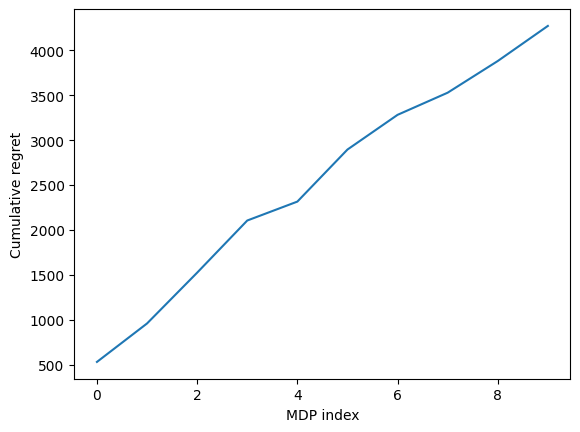

In [4]:
cum_regret = np.cumsum(regrets)

plt.plot(cum_regret)
plt.xlabel("MDP index")
plt.ylabel("Cumulative regret")